#Q1. A company conducted a survey of its employees and found that 70% of the employees use the company's health insurance plan, while 40% of the employees who use the plan are smokers. What is the probability that an employee is a smoker given that he/she uses the health insurance plan?
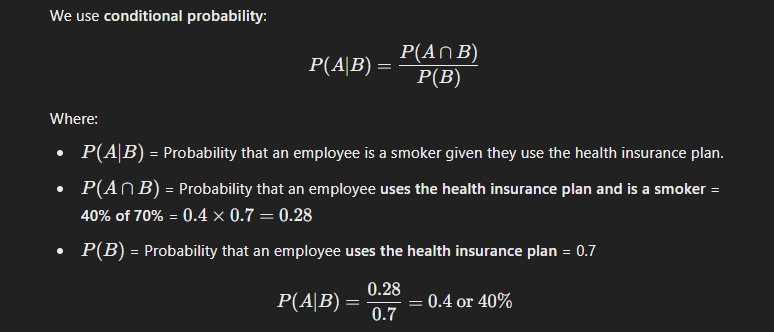


#Q2. What is the difference between Bernoulli Naive Bayes and Multinomial Naive Bayes?

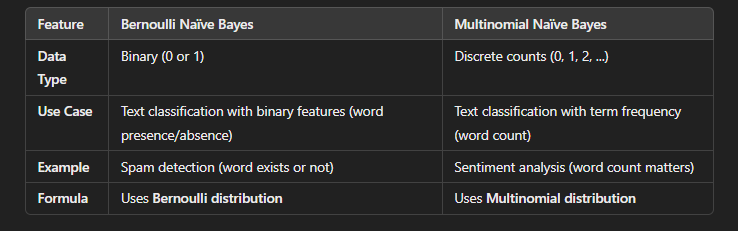
#Q3. How does Bernoulli Naive Bayes handle missing values?

Bernoulli Naïve Bayes assumes binary features (0 or 1), so missing values are often treated as absent (0).
If missing values are not explicitly handled, sklearn’s BernoulliNB may treat them as zeros, which might affect predictions.
A common approach is:
Impute missing values (e.g., with the mode or mean).
Use a separate category (e.g., -1) to represent missing data.

Q4. Can Gaussian Naive Bayes be used for multi-class classification?

In [2]:
'''Yes, Gaussian Naïve Bayes (GNB) can handle multi-class classification using the one-vs-rest (OvR) strategy.

It calculates probability distributions for each class assuming a normal distribution of features.
It predicts the class with the highest posterior probability.
Example: Handwritten digit classification (0–9) in the MNIST dataset.'''

'Yes, Gaussian Naïve Bayes (GNB) can handle multi-class classification using the one-vs-rest (OvR) strategy.\n\nIt calculates probability distributions for each class assuming a normal distribution of features.\nIt predicts the class with the highest posterior probability.\nExample: Handwritten digit classification (0–9) in the MNIST dataset.'

Q5. Assignment:
Data preparation:
Download the "Spambase Data Set" from the UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/
datasets/Spambase). This dataset contains email messages, where the goal is to predict whether a message
is spam or not based on several input features.
Implementation:
Implement Bernoulli Naive Bayes, Multinomial Naive Bayes, and Gaussian Naive Bayes classifiers using the
scikit-learn library in Python. Use 10-fold cross-validation to evaluate the performance of each classifier on the
dataset. You should use the default hyperparameters for each classifier.
Results:
Report the following performance metrics for each classifier:
Accuracy
Precision
Recall
F1 score
Discussion:
Discuss the results you obtained. Which variant of Naive Bayes performed the best? Why do you think that is
the case? Are there any limitations of Naive Bayes that you observed?
Conclusion:
Summarise your findings and provide some suggestions for future work.

BernoulliNB - Accuracy: 0.8853
MultinomialNB - Accuracy: 0.7918
GaussianNB - Accuracy: 0.8207
               Accuracy  Precision    Recall  F1-score
BernoulliNB    0.880565   0.906977  0.800000  0.850136
MultinomialNB  0.786102   0.764384  0.715385  0.739073
GaussianNB     0.820847   0.719298  0.946154  0.817276


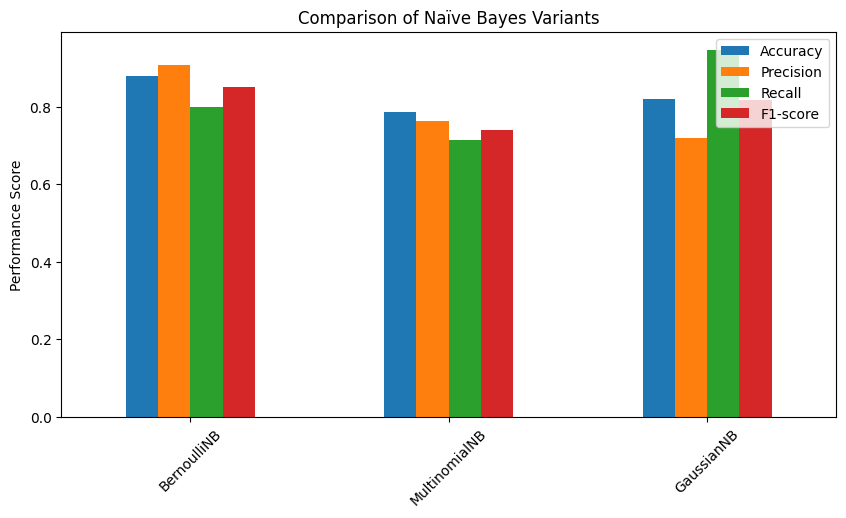

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import BernoulliNB, MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
columns_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.names"

# Read data
spambase = pd.read_csv(url, header=None)

# Last column is the target (1=spam, 0=not spam)
X = spambase.iloc[:, :-1]  # Features
y = spambase.iloc[:, -1]   # Target

# Standardize data for GaussianNB
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Naive Bayes models
models = {
    "BernoulliNB": BernoulliNB(),
    "MultinomialNB": MultinomialNB(),
    "GaussianNB": GaussianNB()
}

# Evaluate models using 10-fold cross-validation
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    }

    print(f"{name} - Accuracy: {scores.mean():.4f}")

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results).T
print(results_df)

# Plot results
results_df.plot(kind='bar', figsize=(10, 5))
plt.title("Comparison of Naïve Bayes Variants")
plt.ylabel("Performance Score")
plt.xticks(rotation=45)
plt.show()
